타이타닉 생존자 예측을 위한 EDA
**생존자 데이터 분석에서 나이,성별 중요함**


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
# 한국어폰트(윈도우)
plt.rcParams["font.family"] = "Malgun Gothic"
# 맥 => AppleGothic

plt.rcParams["axes.unicode_minus"] = False

In [46]:
# 타이타닉 데이터 불러오기 (pandas)
import seaborn as sns
df=sns.load_dataset("titanic")
df.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [11]:
# 나이채우기
# 경고수정하기 inplace
# df["age"] == select age from df
df["age"]=df["age"].fillna(df["age"].mean())
df["embarked"].fillna(df["embarked"].mode()[0])
# # df.info()

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: embarked, Length: 891, dtype: object

In [12]:
# mode()=>embarked채우기 (최빈도/가장많이 나온값)
# 유튜브 박조은 todaycode
df["embarked"].mode()[0]

'S'

In [13]:
# 결측치를 최빈값으로 채우기
df["embarked"]=df["embarked"].fillna(df["embarked"].mode()[0])
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


생존자 현황

In [45]:
# 생존자 수
survived_count = df["survived"].value_counts()

# 생존자 비율
survived_rate = df["survived"].mean()
print(f"생존자:{survived_count[1]}명")
print(f"사망자:{survived_count[0]}명")
print(f"생존율:{survived_rate:.2%}")

생존자:342명
사망자:549명
생존율:38.38%


In [47]:
# 카테시안곱 -> 두 집합의 모든 가능한 쌍을 만드는 조합
# 경우의 수를 만들어줌
pd.crosstab(df["sex"],df["survived"])

# 여성 중 사망자 수: 81
# 여성 중 생존자 수: 233
# 남성 중 사망자 수: 468
# 남성 중 생존자 수: 109

survived,0,1
sex,,
female,81,233
male,468,109


survived,0,1
sex,,
female,81,233
male,468,109


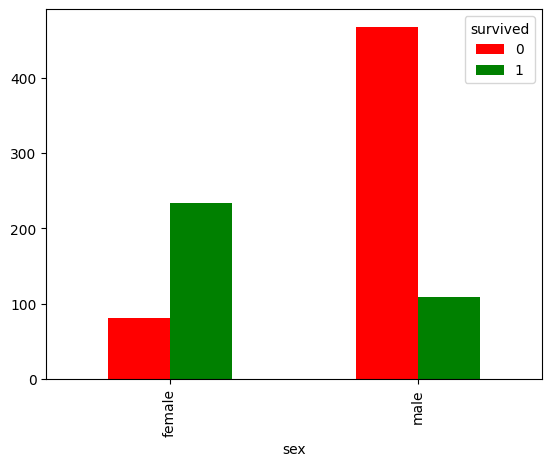

In [ ]:
# 1. 교차표 만들기 pd.crosstab()
# 	 : 성별 vs 생존여부 도수표 만들기
gender_survival_counts = pd.crosstab(df["sex"],df["survived"])


# 2. 막대그래프 그리기
#    :빨강(사망)/초록(생존) 막대그래프
# 판다스는 젤먼저 인덱스 x로 지정됨 
gender_survival_counts.plot(kind="bar", color=["red","green"])
# gender_survival_counts

seaborn

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


<Axes: xlabel='sex', ylabel='count'>

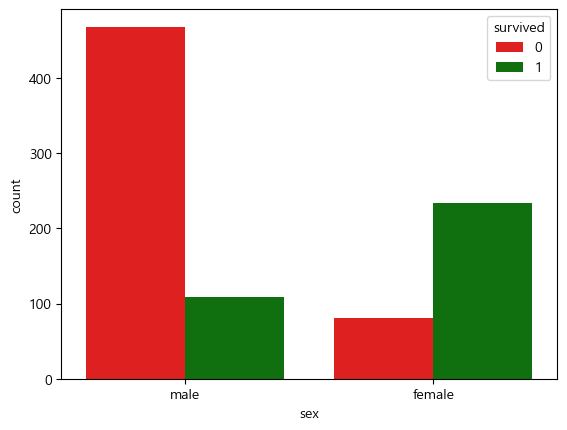

In [44]:
# conunplot => 어떤 '컬럼'의 값을 기준으로 할지 x||y
# hue => 색상 구분을 통해 데이터 그룹별 시각화
# 이그래프는 의미가 부족(생존률,생존자 ... 더 필요!)
df.info()
# sns.countplot(x="sex", y="survived",data=df)
sns.countplot(data=df,x="sex", hue="survived", palette=["red","green"])

## 1. 성별에 따른 생존율 분석

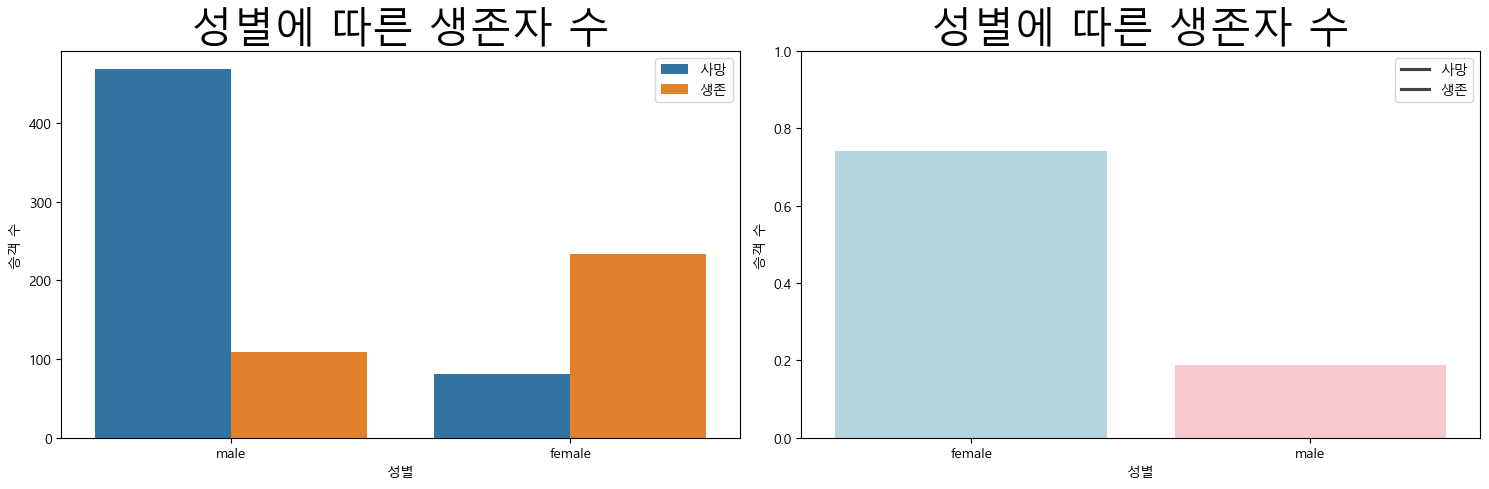

In [15]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,2,figsize=(15,5))

# 등급별 생존자 수
sns.countplot(data=df, x="sex", hue="survived", ax=axes[0])
axes[0].set_title("성별에 따른 생존자 수", fontsize=30)
axes[0].set_xlabel("성별")
axes[0].set_ylabel("승객 수")
axes[0].legend(labels=["사망","생존"])

# 성별 생존율 구하기!
# sns.barplot(data=sex_survived ,x="sex",y="survived", ax=axes[1])

# 집계함수 -> 판다스에서 잘안씀
sex_survived = df.groupby("sex")["survived"].mean().reset_index()
sns.barplot(data=sex_survived ,x="sex",y="survived",  hue="sex", ax=axes[1], palette=["lightblue","pink"])
axes[1].set_title("성별에 따른 생존자 수", fontsize=30)
axes[1].set_xlabel("성별")
axes[1].set_ylabel("승객 수")
axes[1].legend(labels=["사망","생존"])
axes[1].set_ylim(0,1)

plt.tight_layout()
plt.show();

## 2. 승객 등급에 따른 생존율
    2-1.등급별 생존자 수
    2-2.등급별 생존율
    2-3.등급별 성별 교차표

C:\Users\user\AppData\Local\Temp\ipykernel_2784\4209176566.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pclass_survived ,x="pclass",y="survived", ax=axes[1], palette=["lightblue","pink"])
C:\Users\user\AppData\Local\Temp\ipykernel_2784\4209176566.py:14: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=pclass_survived ,x="pclass",y="survived", ax=axes[1], palette=["lightblue","pink"])


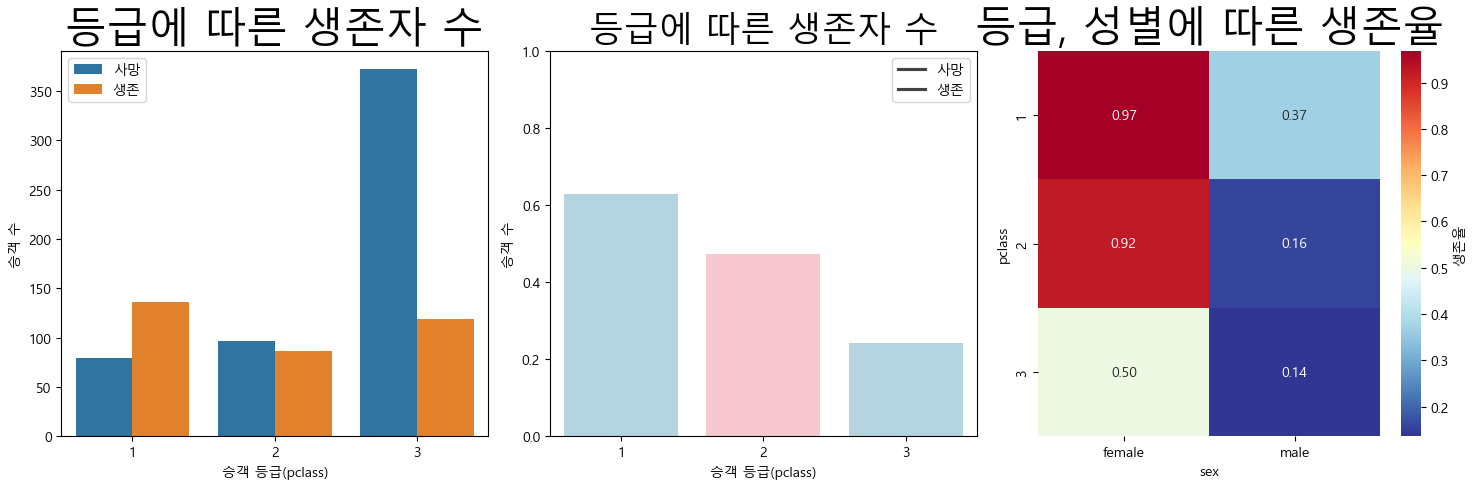

In [42]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,3,figsize=(15,5))

# 2-1. 등급별 생존자 수 (독립변인 => pclass)
# sns.countplot(data=df, x="sex", hue="survived", ax=axes[0])
sns.countplot(data=df, x="pclass", hue="survived", ax=axes[0])
axes[0].set_title("등급에 따른 생존자 수", fontsize=30)
axes[0].set_xlabel("승객 등급(pclass)")
axes[0].set_ylabel("승객 수")
axes[0].legend(labels=["사망","생존"])

# 2-2. 등급별 생존율 
pclass_survived = df.groupby("pclass")["survived"].mean().reset_index()
sns.barplot(data=pclass_survived ,x="pclass",y="survived", ax=axes[1], palette=["lightblue","pink"])
axes[1].set_title("등급에 따른 생존자 수", fontsize=25)
axes[1].set_xlabel("승객 등급(pclass)")
axes[1].set_ylabel("승객 수")
axes[1].legend(labels=["사망","생존"])
axes[1].set_ylim(0,1)

# 2-3. 히트맵 : 등급 + 성별 생존율
# aggfunc : 집계함수(기준)
# annot=True : 각 셀 안에 실제 숫자 값을 표시
cross_tab= pd.crosstab(df["pclass"],df["sex"],values=df["survived"], aggfunc="mean")
sns.heatmap(cross_tab, annot=True, fmt=".2f", cmap="RdYlBu_r", cbar_kws={"label":"생존율"}, ax=axes[2])
axes[2].set_title("등급, 성별에 따른 생존율", fontsize=30)

plt.tight_layout()
plt.show();

In [27]:
pd.crosstab(df["pclass"],df["sex"],values=df["survived"], aggfunc="mean")

sex,female,male
pclass,,
1,0.968085,0.368852
2,0.921053,0.157407
3,0.500000,0.135447


In [35]:
df["age"]

0      22.000000
1      38.000000
2      26.000000
3      35.000000
4      35.000000
         ...    
886    27.000000
887    19.000000
888    29.699118
889    26.000000
890    32.000000
Name: age, Length: 891, dtype: float64

## 3. 나이에 따른 생존율 분석
    3-1. 성별과 나이 boxplots으로나타내기
    3-2. 전체 나이 분포
    3-3. 그룹별
    3-4. 생존 여부에 따른 나이 분포

C:\Users\user\AppData\Local\Temp\ipykernel_2784\791098818.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_group_survived ,x="age_group",y="survived", ax=axes[1,0], palette=["lightblue","pink"])
C:\Users\user\AppData\Local\Temp\ipykernel_2784\791098818.py:26: UserWarning: 
The palette list has fewer values (2) than needed (7) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=age_group_survived ,x="age_group",y="survived", ax=axes[1,0], palette=["lightblue","pink"])


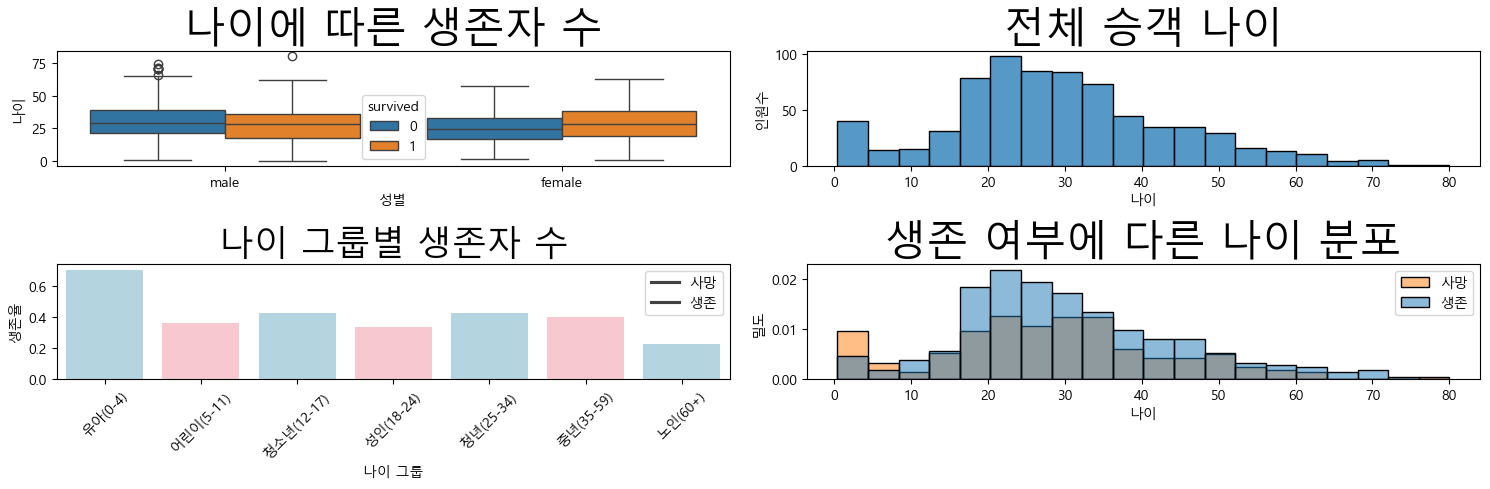

In [ ]:
import matplotlib.pyplot as plt
# 그래프 4개
fig, axes = plt.subplots(2,2,figsize=(15,10))

# 3-1. 성별과 나이(boxplot)
sns.boxplot(data=df, x="sex", y="age", hue="survived", ax=axes[0,0])
axes[0,0].set_title("나이에 따른 생존자 수", fontsize=30)
axes[0,0].set_xlabel("성별")
axes[0,0].set_ylabel("나이")


# 3-2. 전체 나이 분포(histplot)
sns.histplot(data=df, x="age", ax=axes[0,1])
axes[0,1].set_title("전체 승객 나이", fontsize=30)
axes[0,1].set_xlabel("나이")
axes[0,1].set_ylabel("인원수")

# 3-3. 그룹별
# 유아 (0-4) 어린이(5-11) 청소년(12-17) 성인(18-24) 청년(25-34) 중년(35-59) 노인(60+)
# bins = [0,5,12,18,25,35,60,np.inf]
# pd.cut(df["age"], bins)
bins = [0,5,12,18,25,35,60, np.inf]
labels = ["유아(0-4)", "어린이(5-11)", "청소년(12-17)", "성인(18-24)", "청년(25-34)","중년(35-59)", "노인(60+)"]
df["age_group"] = pd.cut(df["age"], bins, labels=labels)
age_group_survived = df.groupby("age_group", observed=True)["survived"].mean().reset_index()
sns.barplot(data=age_group_survived ,x="age_group",y="survived", ax=axes[1,0], palette=["lightblue","pink"])
axes[1,0].set_title("나이 그룹별 생존자 수", fontsize=25)
axes[1,0].set_xlabel("나이 그룹")
axes[1,0].set_ylabel("생존율")
axes[1,0].tick_params(axis="x", rotation=45)
axes[1,0].legend(labels=["사망","생존"])

# 3-4. 생존 여부에 따른 나이 분포
sns.histplot(data=df, x="age", hue="survived", stat="density", ax=axes[1,1])
axes[1,1].set_title("생존 여부에 다른 나이 분포", fontsize=30)
axes[1,1].set_xlabel("나이")
axes[1,1].set_ylabel("밀도")
axes[1,1].legend(labels=["사망","생존"])

plt.tight_layout()
plt.show();

In [ ]:
import matplotlib.pyplot as plt
# 그래프 4개
fig, axes = plt.subplots(2,2,figsize=(15,10))

# 3-1. 성별과 나이(boxplot)
sns.boxplot(data=df, x="sex", y="age", hue="survived", ax=axes[0,0])
axes[0,0].set_title("나이에 따른 생존자 수", fontsize=30)
axes[0,0].set_xlabel("성별")
axes[0,0].set_ylabel("나이")


df["age"].plot(kind="hist", )
axes[0,1].set_title("전체 승객 나이", fontsize=30)
axes[0,1].set_xlabel("나이")
axes[0,1].set_ylabel("인원수")

# 3-3. 그룹별
# 유아 (0-4) 어린이(5-11) 청소년(12-17) 성인(18-24) 청년(25-34) 중년(35-59) 노인(60+)
# bins = [0,5,12,18,25,35,60,np.inf]
# pd.cut(df["age"], bins)
bins = [0,5,12,18,25,35,60, np.inf]
labels = ["유아(0-4)", "어린이(5-11)", "청소년(12-17)", "성인(18-24)", "청년(25-34)","중년(35-59)", "노인(60+)"]
df["age_group"] = pd.cut(df["age"], bins, labels=labels)
age_group_survived = df.groupby("age_group", observed=True)["survived"].mean().reset_index()
sns.barplot(data=age_group_survived ,x="age_group",y="survived", ax=axes[1,0], palette=["lightblue","pink"])
axes[1,0].set_title("나이 그룹별 생존자 수", fontsize=25)
axes[1,0].set_xlabel("나이 그룹")
axes[1,0].set_ylabel("생존율")
axes[1,0].tick_params(axis="x", rotation=45)
axes[1,0].legend(labels=["사망","생존"])

# 3-4. 생존 여부에 따른 나이 분포
sns.histplot(data=df, x="age", hue="survived", stat="density", ax=axes[1,1])
axes[1,1].set_title("생존 여부에 다른 나이 분포", fontsize=30)
axes[1,1].set_xlabel("나이")
axes[1,1].set_ylabel("밀도")
axes[1,1].legend(labels=["사망","생존"])

plt.tight_layout()
plt.show();